<img src="https://www.funcionpublica.gov.co/documents/d/guest/logo-universidad-nacional" alt="Logo UNAL" width="600"/>

### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento del Lenguaje Natural*

#### Profesor: Lucas Iturriago

## Introducción al Procesamiento de Texto y Regex Avanzado

En la ingeniería de datos y NLP, el 80% del tiempo se invierte limpiando datos. Las Expresiones Regulares (Regex) son la herramienta fundamental para transformar texto "sucio" (logs, tweets, HTML, PDFs) en datos estructurados. En este notebook no solo buscaremos patrones, sino que aprenderemos a:

1. Usar **Regex Avanzado** (Grupos con nombre, Lookaheads).
2. Integrar Regex directamente en **Pandas** sin usar bucles `for` (Vectorización).
3. **Normalizar texto** profesionalmente (Unicode, eliminación de acentos).
4. Visualizar leyes lingüísticas (Ley de Zipf).

### Grupos de Captura con Nombre (Named Groups)

Tradicionalmente, usamos paréntesis `()` para crear grupos de captura y accedemos a ellos mediante índices (`group(1)`). El problema es que si modificamos la expresión regular, todos los índices se desplazan, rompiendo el código silenciosamente en producción.

**La Solución:** Asignar un **nombre** a cada grupo directamente dentro del patrón usando la sintaxis `(?P<nombre>patron)`. Esto hace que el código sea autodocumentado y robusto a cambios.

In [1]:
import re

In [2]:
# Texto de ejemplo (Guion de Los Simpson)
texto = """(Jefe de los Minisupers) 14'49'' Podéis hacerme tres preguntas.
(Apu) 14'58'' Qué bueno, porque sólo necesito una.
(Homer) 15'05'' ¿Usted es el Jefe de los Minisupers?
(Jefe de los Minisupers) 15'13'' Así es.
(Homer) 15'22'' ¿Usted?
(Jefe de los Minisupers) 15'38'' Así es.
(Homer) 15'41'' ¿Está seguro?
(Jefe de los Minisupers) 16' Sí. Espero que los haya iluminado.
(Apu) 16'11'' Pero tengo que...
(Jefe de los Minisupers) 16'2'' Gracias. Vuelva pronto.
(Apu) 16'29'' Pero.
(Jefe de los Minisupers) 16'33'' Graciaaaaas. Vuelva pronto."""

In [3]:
print("Texto cargado correctamente.\n")

Texto cargado correctamente.



In [4]:
# Patrón robusto con nombres: (?P<nombre_grupo>patron)
patron_avanzado = r"\((?P<personaje>.+?)\)\s+(?P<tiempo>\d{1,2}'(?:\d{0,2}''?)?)\s+(?P<dialogo>.*)"

In [5]:
for match in re.finditer(patron_avanzado, texto):
    # Accedemos por nombre, mucho más seguro que usar índices
    print(f"Personaje: {match.group('personaje')} | Dice: {match.group('dialogo')[:20]}...")

Personaje: Jefe de los Minisupers | Dice: Podéis hacerme tres ...
Personaje: Apu | Dice: Qué bueno, porque só...
Personaje: Homer | Dice: ¿Usted es el Jefe de...
Personaje: Jefe de los Minisupers | Dice: Así es....
Personaje: Homer | Dice: ¿Usted?...
Personaje: Jefe de los Minisupers | Dice: Así es....
Personaje: Homer | Dice: ¿Está seguro?...
Personaje: Jefe de los Minisupers | Dice: Sí. Espero que los h...
Personaje: Apu | Dice: Pero tengo que......
Personaje: Jefe de los Minisupers | Dice: Gracias. Vuelva pron...
Personaje: Apu | Dice: Pero....
Personaje: Jefe de los Minisupers | Dice: Graciaaaaas. Vuelva ...


### Lookarounds: Búsqueda sin Consumo


Los **Lookarounds** separan a un principiante de un experto. Son aserciones que validan si un patrón existe antes o después de nuestra posición actual, pero **NO mueven el cursor ni incluyen esos caracteres en el resultado extraído**.

* **Positive Lookahead `(?=...)`**: "¿Lo que sigue a mi derecha coincide con esto?"
* **Positive Lookbehind `(?<=...)`**: "¿Lo que está a mi izquierda coincide con esto?"

In [6]:
# EJEMPLO LOOKAHEAD: Extraer solo los minutos, asegurando que tienen una comilla simple (') JUSTO DESPUÉS.
tiempos = re.findall(r"\d+(?=')", texto)
print("Minutos encontrados (usando Lookahead):", tiempos)

Minutos encontrados (usando Lookahead): ['14', '49', '14', '58', '15', '05', '15', '13', '15', '22', '15', '38', '15', '41', '16', '16', '11', '16', '2', '16', '29', '16', '33']


In [7]:
# EJEMPLO LOOKBEHIND: Encontrar diálogos que ocurran después de Apu
dialogos_apu = re.findall(r"(?<=\(Apu\) \d\d'\d\d'' ).*", texto)
print("Diálogos de Apu (usando Lookbehind):", dialogos_apu)

Diálogos de Apu (usando Lookbehind): ['Qué bueno, porque sólo necesito una.', 'Pero tengo que...', 'Pero.']


## Ingeniería de Características con Pandas

### El "Anti-Patrón" de los bucles `for` y la Vectorización

Iterar sobre un DataFrame usando bucles `for` para aplicar regex es ineficiente y lento en Python. La solución profesional es usar el accesor especial `.str` de Pandas.


Este accesor aplica operaciones a **toda la columna a la vez** (optimizadas en C). La joya de la corona es `.str.extract()`, que al combinarse con Grupos con Nombre, convierte automáticamente las capturas en nuevas columnas del DataFrame.

In [8]:
import pandas as pd

In [9]:
# Configuración de visualización
pd.set_option('display.max_colwidth', None)

In [10]:
# Creamos el DataFrame inicial (simulando lectura de archivo)
lineas = texto.split('\n')
df = pd.DataFrame(lineas, columns=['raw_text'])

In [11]:
# Extracción Vectorizada: Pandas convierte automáticamente los grupos en columnas
df_procesado = df['raw_text'].str.extract(patron_avanzado)

In [12]:
print("DataFrame extraído vectorizadamente:")
print(df_procesado.head(3))

DataFrame extraído vectorizadamente:
                personaje   tiempo                               dialogo
0  Jefe de los Minisupers  14'49''        Podéis hacerme tres preguntas.
1                     Apu  14'58''  Qué bueno, porque sólo necesito una.
2                   Homer  15'05''  ¿Usted es el Jefe de los Minisupers?


### Limpieza, Tipado (Casting) y Filtrado

Una vez extraído el texto, sigue siendo un `string`. Debemos limpiarlo y convertirlo a formato numérico usando `pd.to_numeric()`. Además, los métodos vectorizados nos permiten filtrar grandes volúmenes de texto de manera eficiente usando `str.contains()`.

In [13]:
# Separamos por la comilla simple de forma vectorizada
tiempo_split = df_procesado['tiempo'].str.split("'", expand=True)

In [14]:
# Casting seguro a numérico
df_procesado['minutos'] = pd.to_numeric(tiempo_split[0])

In [15]:
# Limpiamos los segundos (quitamos comillas extra) y convertimos a número
df_procesado['segundos'] = tiempo_split[1].str.replace("''", "", regex=False)
df_procesado['segundos'] = pd.to_numeric(df_procesado['segundos'], errors='coerce').fillna(0)

In [16]:
print("\nDataFrame con tiempos numéricos:")
print(df_procesado[['personaje', 'minutos', 'segundos', 'dialogo']].head(3))


DataFrame con tiempos numéricos:
                personaje  minutos  segundos  \
0  Jefe de los Minisupers       14      49.0   
1                     Apu       14      58.0   
2                   Homer       15       5.0   

                                dialogo  
0        Podéis hacerme tres preguntas.  
1  Qué bueno, porque sólo necesito una.  
2  ¿Usted es el Jefe de los Minisupers?  


In [17]:
# Filtrado Avanzado: Encontrar diálogos de Apu o Homer ignorando mayúsculas
filtro_personajes = df_procesado['personaje'].str.contains(r'Apu|Homer', case=False, regex=True).fillna(False)
df_filtrado = df_procesado[filtro_personajes]

In [18]:
print(f"\nFilas originales: {len(df_procesado)}, Filas filtradas (Solo Apu/Homer): {len(df_filtrado)}")


Filas originales: 12, Filas filtradas (Solo Apu/Homer): 6


## Normalización y Lingüística Computacional

### El Infierno de la Codificación y la Normalización Unicode

En español, una letra como la "ñ" o una vocal con tilde ("á") puede representarse de múltiples formas binarias en la computadora. Usar `.replace('á', 'a')` es ineficiente y propenso a errores.


La forma profesional es usar la **Descomposición Canónica (NFD)** mediante la librería `unicodedata`. Esto separa el caracter base ('a') de su diacrítico ('´'), permitiéndonos filtrar fácilmente los acentos.

In [19]:
import unicodedata

In [20]:
def normalizar_texto(texto):
    """
    Convierte a minúsculas, separa tildes de letras mediante NFD y deja solo caracteres alfanuméricos.
    """
    texto = texto.lower()
    # NFD separa letras de tildes. Filtramos la categoría 'Mn' (Mark, nonspacing)
    texto_limpio = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    # Dejamos solo letras, números y espacios
    texto_limpio = re.sub(r'[^a-zA-Z0-9\s]', '', texto_limpio)

    return texto_limpio

In [21]:
texto_sucio = "¡Hola! ¿Cómo estás hoy, pingüino? El camión pasó por aquí."
print(f"Original: {texto_sucio}")
print(f"Normalizado: {normalizar_texto(texto_sucio)}")

Original: ¡Hola! ¿Cómo estás hoy, pingüino? El camión pasó por aquí.
Normalizado: hola como estas hoy pinguino el camion paso por aqui


### Tokenización y Lemmatización (Spacy vs NLTK)

Para reducir el vocabulario y entender de qué habla un texto, tenemos dos estrategias principales:
* **Stemming (ej. NLTK):** Recorta palabras basándose en reglas ("corriendo" -> "corr"). Es rápido pero rudimentario.
* **Lemmatización (ej. SpaCy):** Análisis morfológico real que busca la forma base en el diccionario ("corriendo" -> "correr"). Es el estándar en la industria.

In [22]:
# Nota: En un entorno real, asegúrate de instalar el modelo antes:
!python -m spacy download es_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 91.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [23]:
import spacy

In [24]:
try:
    nlp = spacy.load("es_core_news_sm")
    texto_nlp = "Los niños están corriendo rápido en las casas grandes"
    doc = nlp(texto_nlp)

    tokens_data = [[t.text, t.lemma_, t.pos_, t.is_stop] for t in doc]
    df_nlp = pd.DataFrame(tokens_data, columns=['Token', 'Lema', 'POS', 'Stopword'])
    print("\nAnálisis morfológico con SpaCy:")
    print(df_nlp)
except OSError:
    print("Modelo de SpaCy no encontrado. Instálalo usando: python -m spacy download es_core_news_sm")


Análisis morfológico con SpaCy:
       Token    Lema   POS  Stopword
0        Los      el   DET      True
1      niños    niño  NOUN     False
2      están   estar   AUX      True
3  corriendo  correr  VERB     False
4     rápido  rápido   ADJ     False
5         en      en   ADP      True
6        las      el   DET      True
7      casas    casa  NOUN     False
8    grandes  grande   ADJ      True


## Ejercicios Prácticos y Casos de Estudio

A continuación aplicamos los conceptos de limpieza y regex avanzados a escenarios típicos de manipulación de datos.

In [28]:
import nltk
from nltk import sent_tokenize
nltk.download('punkt_tab', quiet=True)

True

In [29]:
# --- Ejercicio 1: Limpieza de cadenas basura ---
a, b, c, d = "xxxxxxxxxxxxxxxx veces ", 1000, "xxxno puedo soñar xxxxx", "xlxaxsx xmxixsxmxaxsx xcxoxsxaxs"
frase_final = f"{re.sub(r'x+', '', c)} {str(b)} {a[-6:]} {re.sub(r'x', '', d)}"
print(f"Ejercicio 1 (Frase limpia): \"{frase_final}\"")

Ejercicio 1 (Frase limpia): "no puedo soñar  1000 veces  las mismas cosas"


In [30]:
# --- Ejercicio 2: Conteo granular ---
texto_ej2 = "Citadme diciendo que me han citado mal. Claro que lo entiendo. Incluso un niño de cinco años podría entenderlo. ¡Que me traigan un niño de cinco años!"
oraciones = nltk.sent_tokenize(texto_ej2, language='spanish')

In [31]:
solo_letras = re.findall(r'[a-zA-ZáéíóúñÁÉÍÓÚÑ]', oraciones[2])
palabras_totales = re.findall(r'\w+', texto_ej2)

In [32]:
print(f"Ejercicio 2a (Letras en Oración 3): {len(solo_letras)}")
print(f"Ejercicio 2b (Total palabras): {len(palabras_totales)}")

Ejercicio 2a (Letras en Oración 3): 40
Ejercicio 2b (Total palabras): 27


In [33]:
# --- Ejercicio 3: Regex avanzado para fechas ---
texto_ej3 = "compras de julio: el 02/07 yerba, 5/7/18 azucar y 8/7 cafe. Agosto: 02-08-2018, 15-8-2018 y 29-08 mas yerba "
# Usamos un Non-capturing group (?:...) para el año opcional
patron_fecha = r"\d{1,2}[/-]\d{1,2}(?:[/-]\d{2,4})?"
print(f"Ejercicio 3 (Fechas extraídas): {re.findall(patron_fecha, texto_ej3)}")

Ejercicio 3 (Fechas extraídas): ['02/07', '5/7/18', '8/7', '02-08-2018', '15-8-2018', '29-08']


### Caso de Estudio: Análisis de Noticias Financieras

Alineados con el preprocesamiento exhaustivo, en el siguiente bloque vamos a:
1. Limpiar completamente un texto financiero.
2. Eliminar las **Stopwords** (palabras vacías) usando NLTK.
3. Extraer cifras monetarias complejas ignorando el formato regional.

In [34]:
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

True

In [35]:
texto_ej4 = 'Jueves 29.3.2018 BUENOS AIRES\n INGRESAR EDICIÓN IMPRESA... El BCRA intervino por séptima rueda consecutiva y el dólar cedió cinco centavos a $ 20,49... Operadores estimaron que la autoridad monetaria habría vendido unos u$s 100 millones, con lo que en el mes llevaría desembolsado cerca de u$s 1.800 millones.'

In [36]:
# 1. Normalización y Stopwords
texto_limpio = normalizar_texto(texto_ej4)
tokens = texto_limpio.split()

In [37]:
stop_list = set(stopwords.words('spanish'))
tokens_sin_sw = [w for w in tokens if w not in stop_list]
frecuencia = pd.Series(tokens_sin_sw).value_counts()

In [38]:
print(f"Reducción por Stopwords: De {len(tokens)} a {len(tokens_sin_sw)} palabras ({(1 - len(tokens_sin_sw)/len(tokens))*100:.1f}%)")

Reducción por Stopwords: De 47 a 33 palabras (29.8%)


In [39]:
# 2. Extracción Monetaria Compleja
# Busca el símbolo de pesos o dólares, la cifra con puntos/comas, y la palabra opcional "millones"
patron_dinero = r"(u\$s|\$)\s*([\d.,]+)\s*(millones)?"
matches = re.findall(patron_dinero, texto_ej4, re.IGNORECASE)

In [40]:
def normalizar_dinero(simbolo, valor_str, sufijo):
    valor_limpio = valor_str.replace('.', '').replace(',', '.') # Arregla el formato latino
    try:
        valor_float = float(valor_limpio)
        if sufijo.strip().lower() == "millones":
            valor_float *= 1_000_000
        return valor_float
    except ValueError:
        return 0.0

In [41]:
datos_dinero = [{'Texto': f"{s} {c} {m}".strip(), 'Valor (USD/ARS)': normalizar_dinero(s, c, m)} for s, c, m in matches]
print("\nExtracción Financiera:")
print(pd.DataFrame(datos_dinero).head())


Extracción Financiera:
                Texto  Valor (USD/ARS)
0          $ 20,49...     2.049000e+01
1    u$s 100 millones     1.000000e+08
2  u$s 1.800 millones     1.800000e+09


### La Ley de Zipf

Por último, comprobamos la Ley de Zipf en nuestro texto procesado.


Esta ley lingüística establece que, en un corpus de lenguaje natural, la frecuencia de una palabra es inversamente proporcional a su ranking. Si graficamos el logaritmo de la frecuencia vs el logaritmo del ranking, deberíamos observar una línea recta descendente.

In [42]:
import matplotlib.pyplot as plt

In [43]:
df_frec = pd.DataFrame(frecuencia).reset_index()
df_frec.columns = ['Palabra', 'Frecuencia']
df_frec['Ranking'] = df_frec.index + 1

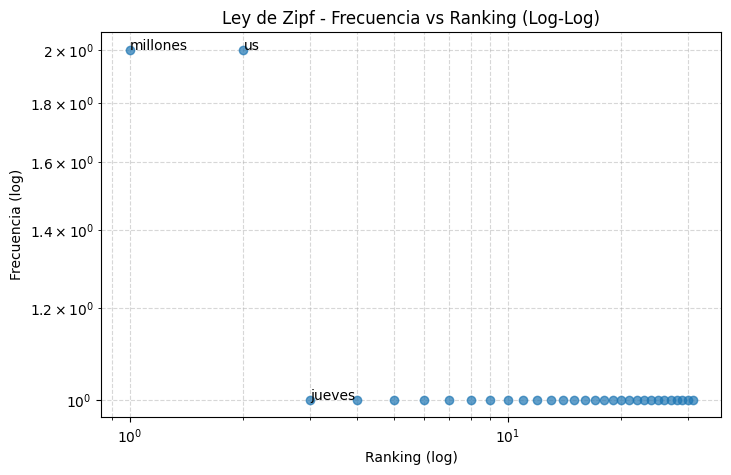

In [48]:
plt.figure(figsize=(8, 5))
plt.loglog(df_frec['Ranking'], df_frec['Frecuencia'], marker='o', linestyle='none', alpha=0.7)
plt.title("Ley de Zipf - Frecuencia vs Ranking (Log-Log)")
plt.xlabel("Ranking (log)")
plt.ylabel("Frecuencia (log)")
plt.grid(True, which="both", ls="--", alpha=0.5)
# Anotamos las top 3 palabras
for i in range(min(3, len(df_frec))):
    plt.annotate(df_frec.iloc[i]['Palabra'], (df_frec.iloc[i]['Ranking'], df_frec.iloc[i]['Frecuencia']))
plt.show()